# Quantum Support Vector Data Description (QSVDD) - Results Visualization

In [20]:
import os
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

In [3]:
plt.style.use('default')

plt.rcParams.update({
    'axes.grid': False,
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',

    'xtick.bottom': True,
    'xtick.top': True,
    'ytick.right': True,
    'ytick.left': True,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'xtick.color': 'black',
    'ytick.color': 'black',

    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'lines.linewidth': 2
})


RESULTS_DIR = os.path.join("..", "results", "training")
DATA_PATH = os.path.join("..", "data", "creditcard.csv")

/tmp/ipykernel_34216/1501792384.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=dataframe, ax=axes[0], palette='viridis')
/tmp/ipykernel_34216/1501792384.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Amount', data=dataframe, ax=axes[1], palette='viridis')


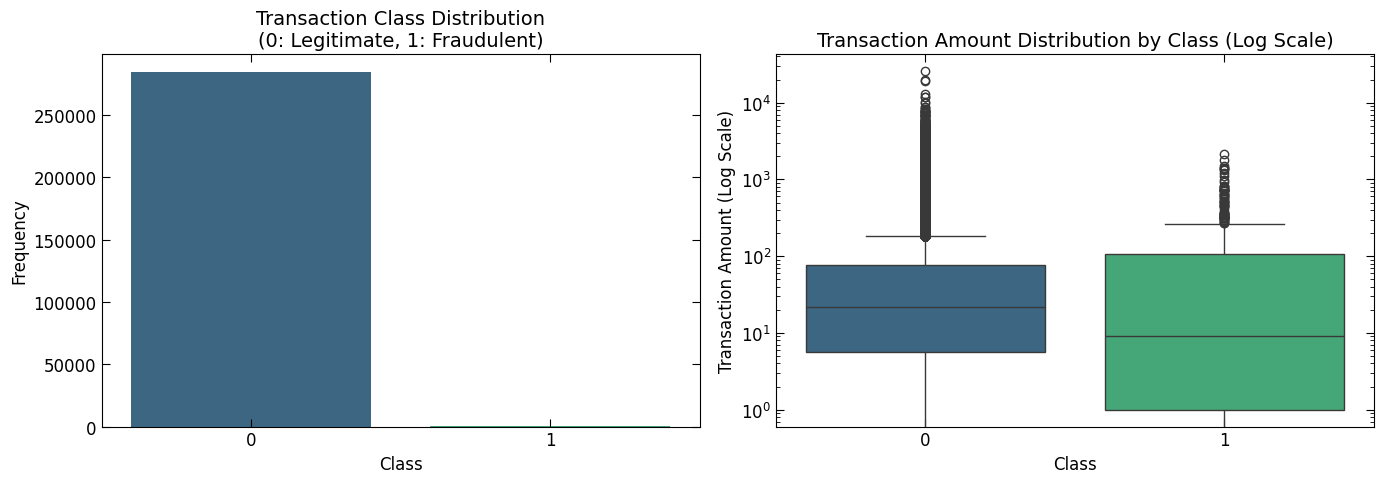

In [2]:
# Load the dataset
try:
    dataframe = pd.read_csv(DATA_PATH)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.countplot(x='Class', data=dataframe, ax=axes[0], palette='viridis')
    axes[0].set_title('Transaction Class Distribution\n(0: Legitimate, 1: Fraudulent)')
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Frequency')

    sns.boxplot(x='Class', y='Amount', data=dataframe, ax=axes[1], palette='viridis')
    axes[1].set_yscale('log')
    axes[1].set_title('Transaction Amount Distribution by Class (Log Scale)')
    axes[1].set_xlabel('Class')
    axes[1].set_ylabel('Transaction Amount (Log Scale)')

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"Dataset not found at {DATA_PATH}. Please verify the path.")

### Functions

In [11]:
def load_data(data_type="LOSS HISTORY", ansatz_name="QCNN", batch_size=4, steps=2000, is_noisy=False):
    """
    Utility function to load any .npy file based on the project's naming convention.

    Parameters:
    - data_type (str): Type of data to load (e.g., 'LOSS HISTORY', 'PARAM HISTORY', 'EST PARAMS', 'EST PARAMS MEAN').
    - ansatz_name (str): The quantum ansatz used ('QCNN', 'QAE', 'LCQHNN').
    - batch_size (int): The batch size used during training.
    - steps (int): The number of steps used during training.
    - is_noisy (bool): Whether to load the noisy training results.
    """
    data_string = data_type.strip().replace(" ", "_").upper()

    noise_str = "_NOISE" if is_noisy else ""

    file_name = f"{ansatz_name.upper()}_B{batch_size:02d}S{steps}{noise_str}_{data_string}.npy"
    file_path = os.path.join(RESULTS_DIR, ansatz_name.upper(), file_name)

    try:
        return np.loadtxt(file_path)
    except FileNotFoundError:
        print(f"Warning: Could not locate {file_path}")
        return None

# --- Usage Examples ---
# loss_data = load_data("LOSS HISTORY", "QAE", 4, 2000)
# est_params_mean_noisy = load_data("EST PARAMS MEAN", "LCQHNN", 8, 2000, is_noisy=True)
# Parameters based on the training script

## Loss Convergence View

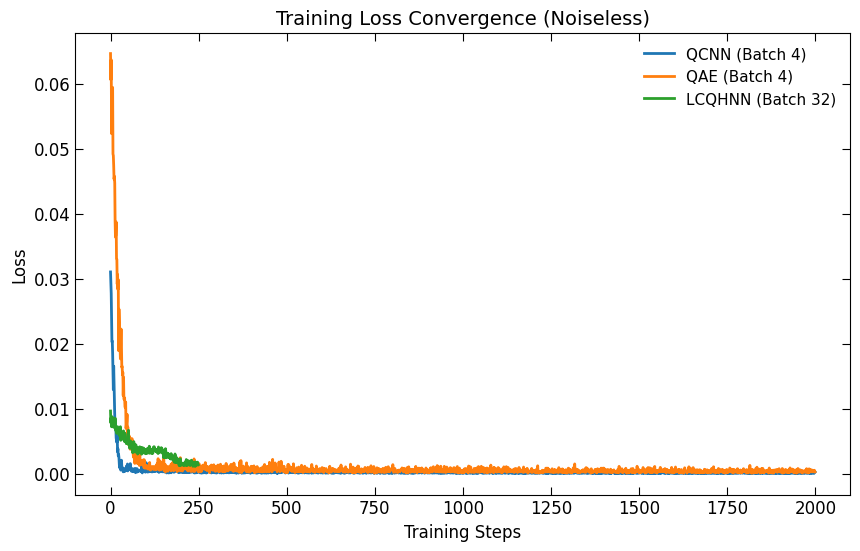

In [15]:
ansatz_list = ['qcnn', 'qae', 'lcqhnn']
batch_list = [4, 4, 32]
steps_list = [2000, 2000, 250]

plt.figure(figsize=(10,6))

for ansatz, batch, steps in zip(ansatz_list, batch_list, steps_list):

    loss_data = load_data("LOSS HISTORY",ansatz, batch, steps, is_noisy=False)

    if loss_data is not None:
        plt.plot(loss_data, label=f'{ansatz.upper()} (Batch {batch})')

plt.title('Training Loss Convergence (Noiseless)')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.legend(loc='best', frameon=False)
plt.show()

## Impact of Quantum Noise on Training

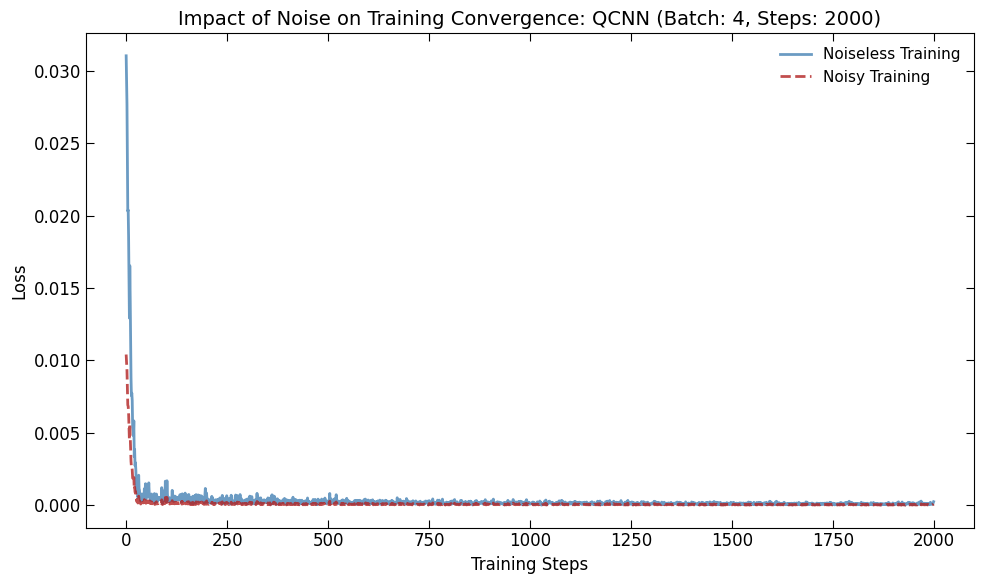

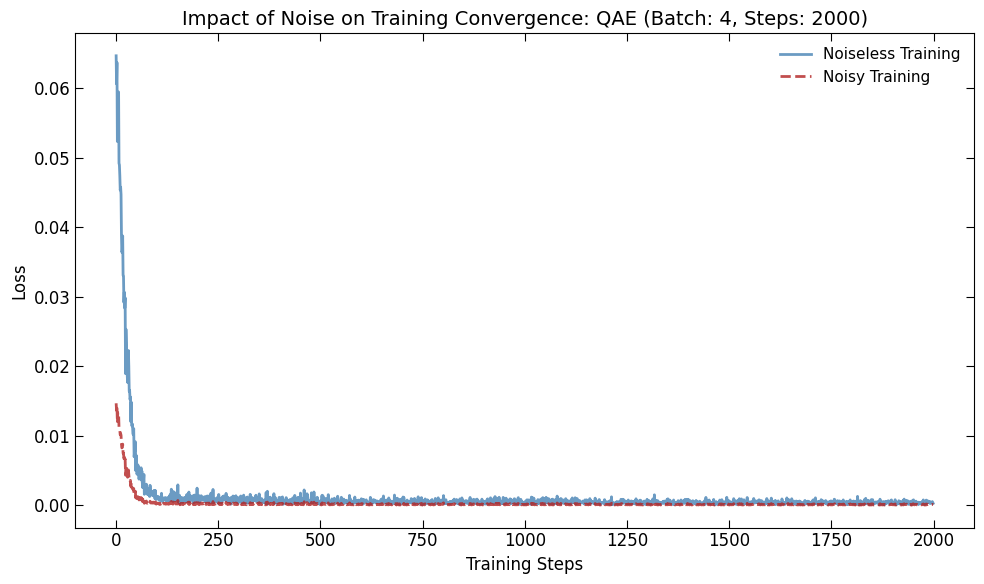

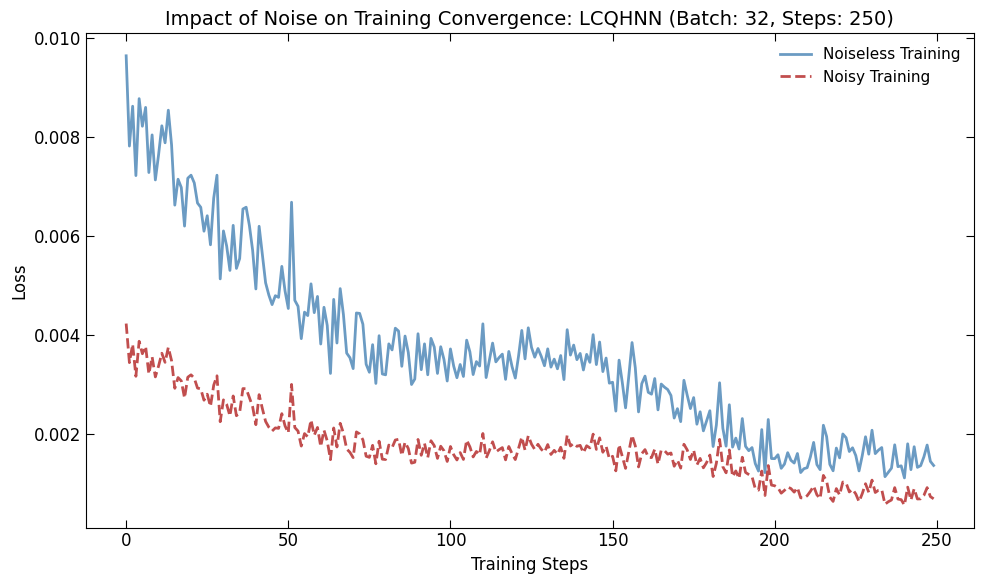

In [16]:
ansatz_list = ['qcnn', 'qae', 'lcqhnn']
batch_list = [4, 4, 32]
steps_list = [2000, 2000, 250]

for ansatz, batch, steps in zip(ansatz_list, batch_list, steps_list):

    # Use the new generalized load_data function
    loss_noiseless = load_data("LOSS HISTORY", ansatz, batch, steps, is_noisy=False)
    loss_noisy = load_data("LOSS HISTORY", ansatz, batch, steps, is_noisy=True)

    plt.figure(figsize=(10, 6))

    if loss_noiseless is not None:
        plt.plot(loss_noiseless, label='Noiseless Training', color='steelblue', alpha=0.8)

    if loss_noisy is not None:
        plt.plot(loss_noisy, label='Noisy Training', color='firebrick', alpha=0.8, linestyle='--')

    # Added batch and steps to the title for better context in the output
    plt.title(f'Impact of Noise on Training Convergence: {ansatz.upper()} (Batch: {batch}, Steps: {steps})')
    plt.xlabel('Training Steps')
    plt.ylabel('Loss')

    # Keeps the clean, box-less legend
    plt.legend(loc='best', frameon=False)

    plt.tight_layout()
    plt.show()

## Parameter Evolution over Time

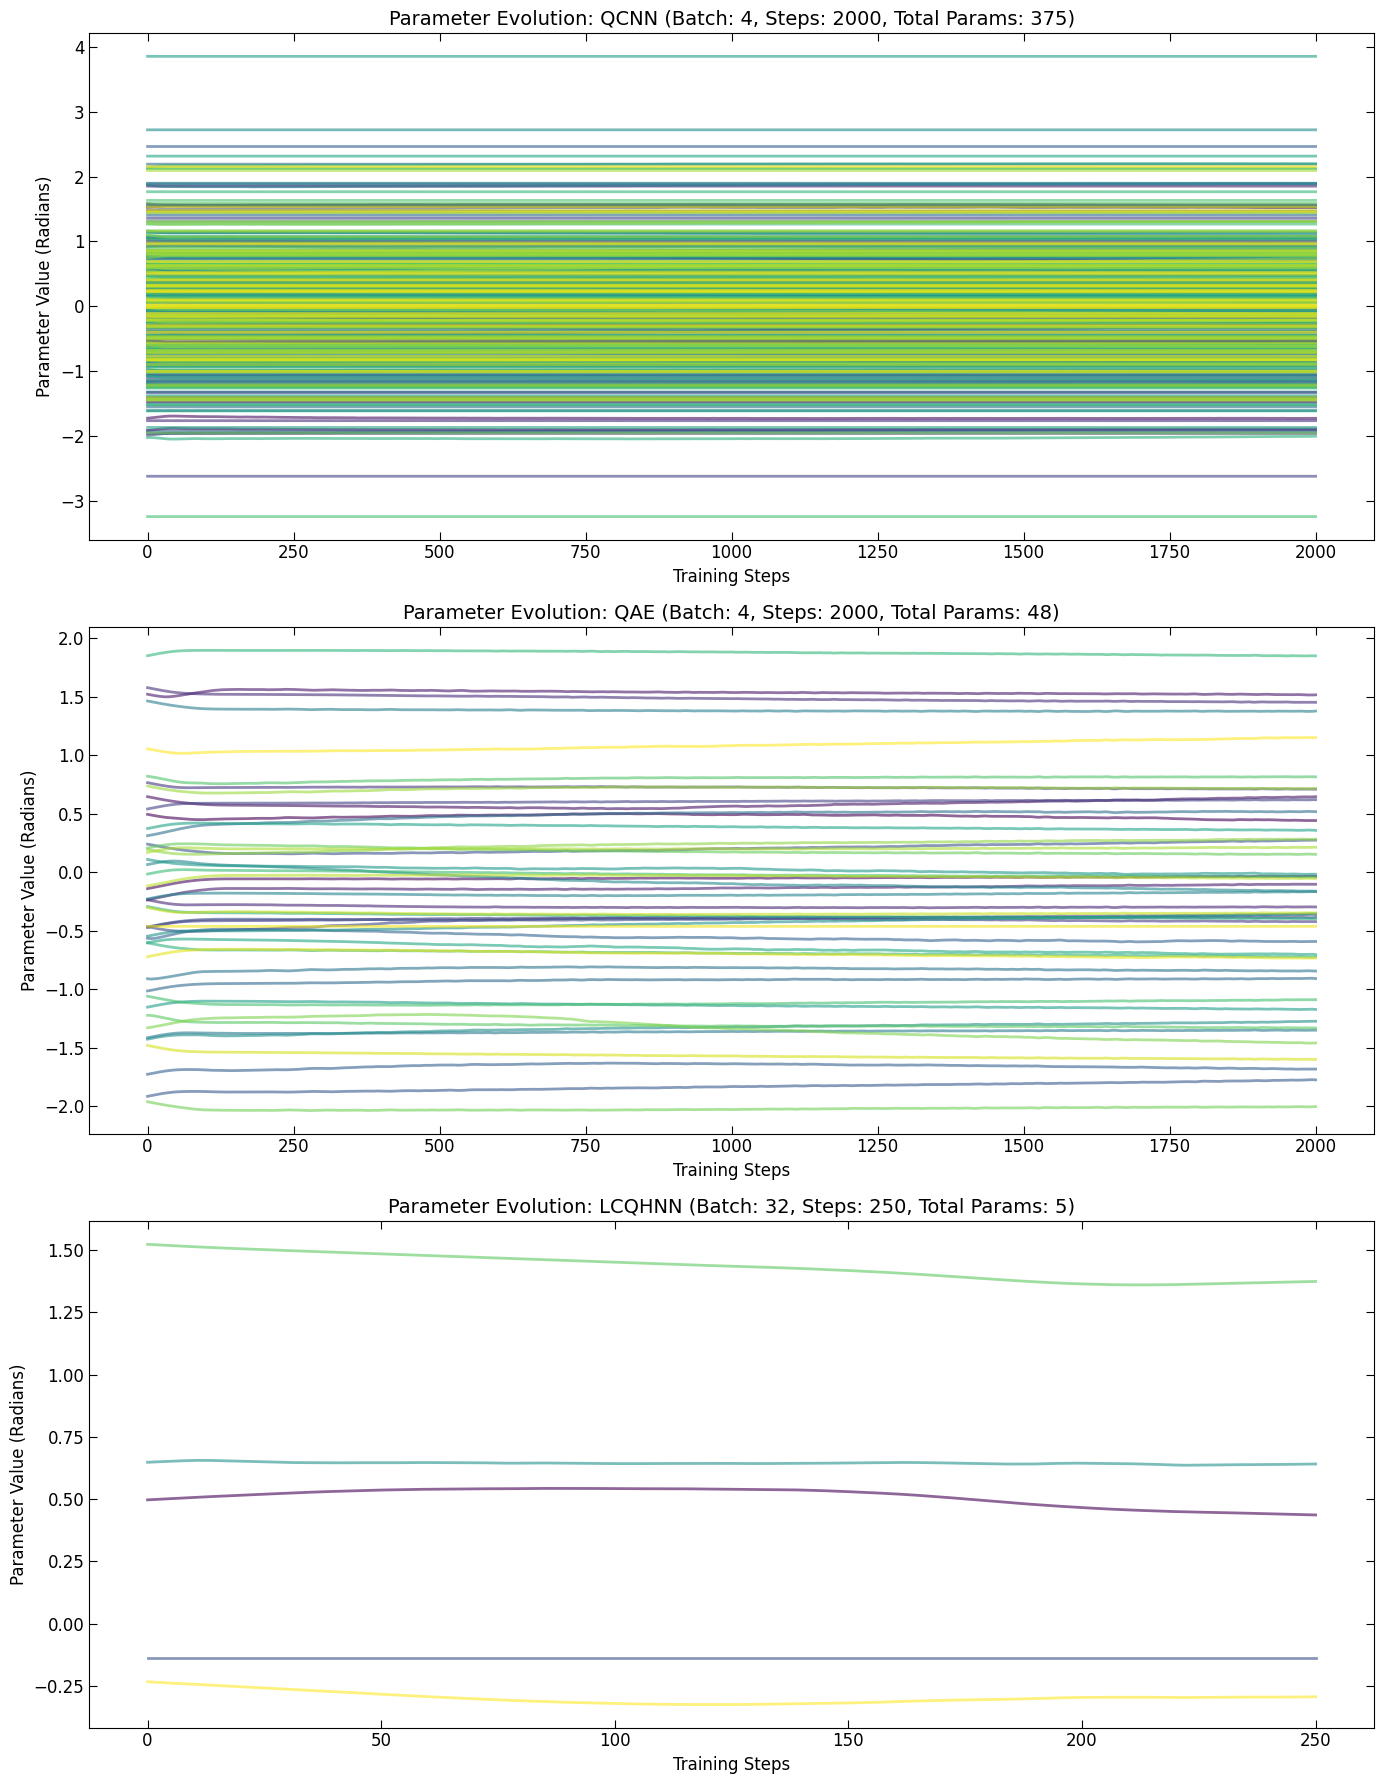

In [19]:
import matplotlib.cm as cm
import numpy as np

# We no longer need the 'color' key here since colors will be dynamic per parameter
ansatz_configurations = [
    {'name': 'qcnn', 'batch_size': 4, 'steps': 2000},
    {'name': 'qae', 'batch_size': 4, 'steps': 2000},
    {'name': 'lcqhnn', 'batch_size': 32, 'steps': 250}
]

figure, axes = plt.subplots(3, 1, figsize=(14, 18))

loaded_data_dictionary = {}

for index, config in enumerate(ansatz_configurations):
    ansatz_type = config['name']
    training_batch = config['batch_size']
    training_steps = config['steps']
    current_axis = axes[index]

    # Use the generalized load_data function
    parameter_history_array = load_data("PARAM HISTORY", ansatz_type, training_batch, training_steps)
    loaded_data_dictionary[ansatz_type] = parameter_history_array

    if parameter_history_array is not None:
        total_parameters = parameter_history_array.shape[1]

        # Generate an array of distinct colors using a colormap (e.g., 'viridis')
        # This guarantees that the colors smoothly transition from start to finish
        line_colors = cm.viridis(np.linspace(0, 1, total_parameters))

        # Iterate through and plot every parameter
        for param_index in range(total_parameters):
            current_axis.plot(
                parameter_history_array[:, param_index],
                alpha=0.6,
                color=line_colors[param_index]  # Assign a unique color to each parameter line
            )

        current_axis.set_title(f'Parameter Evolution: {ansatz_type.upper()} (Batch: {training_batch}, Steps: {training_steps}, Total Params: {total_parameters})')
        current_axis.set_xlabel('Training Steps')
        current_axis.set_ylabel('Parameter Value (Radians)')

    else:
        current_axis.set_title(f'{ansatz_type.upper()} Parameter Data Not Found')
        current_axis.axis('off')

# Ensure the plots do not overlap
plt.tight_layout()
plt.show()

## Params Means View

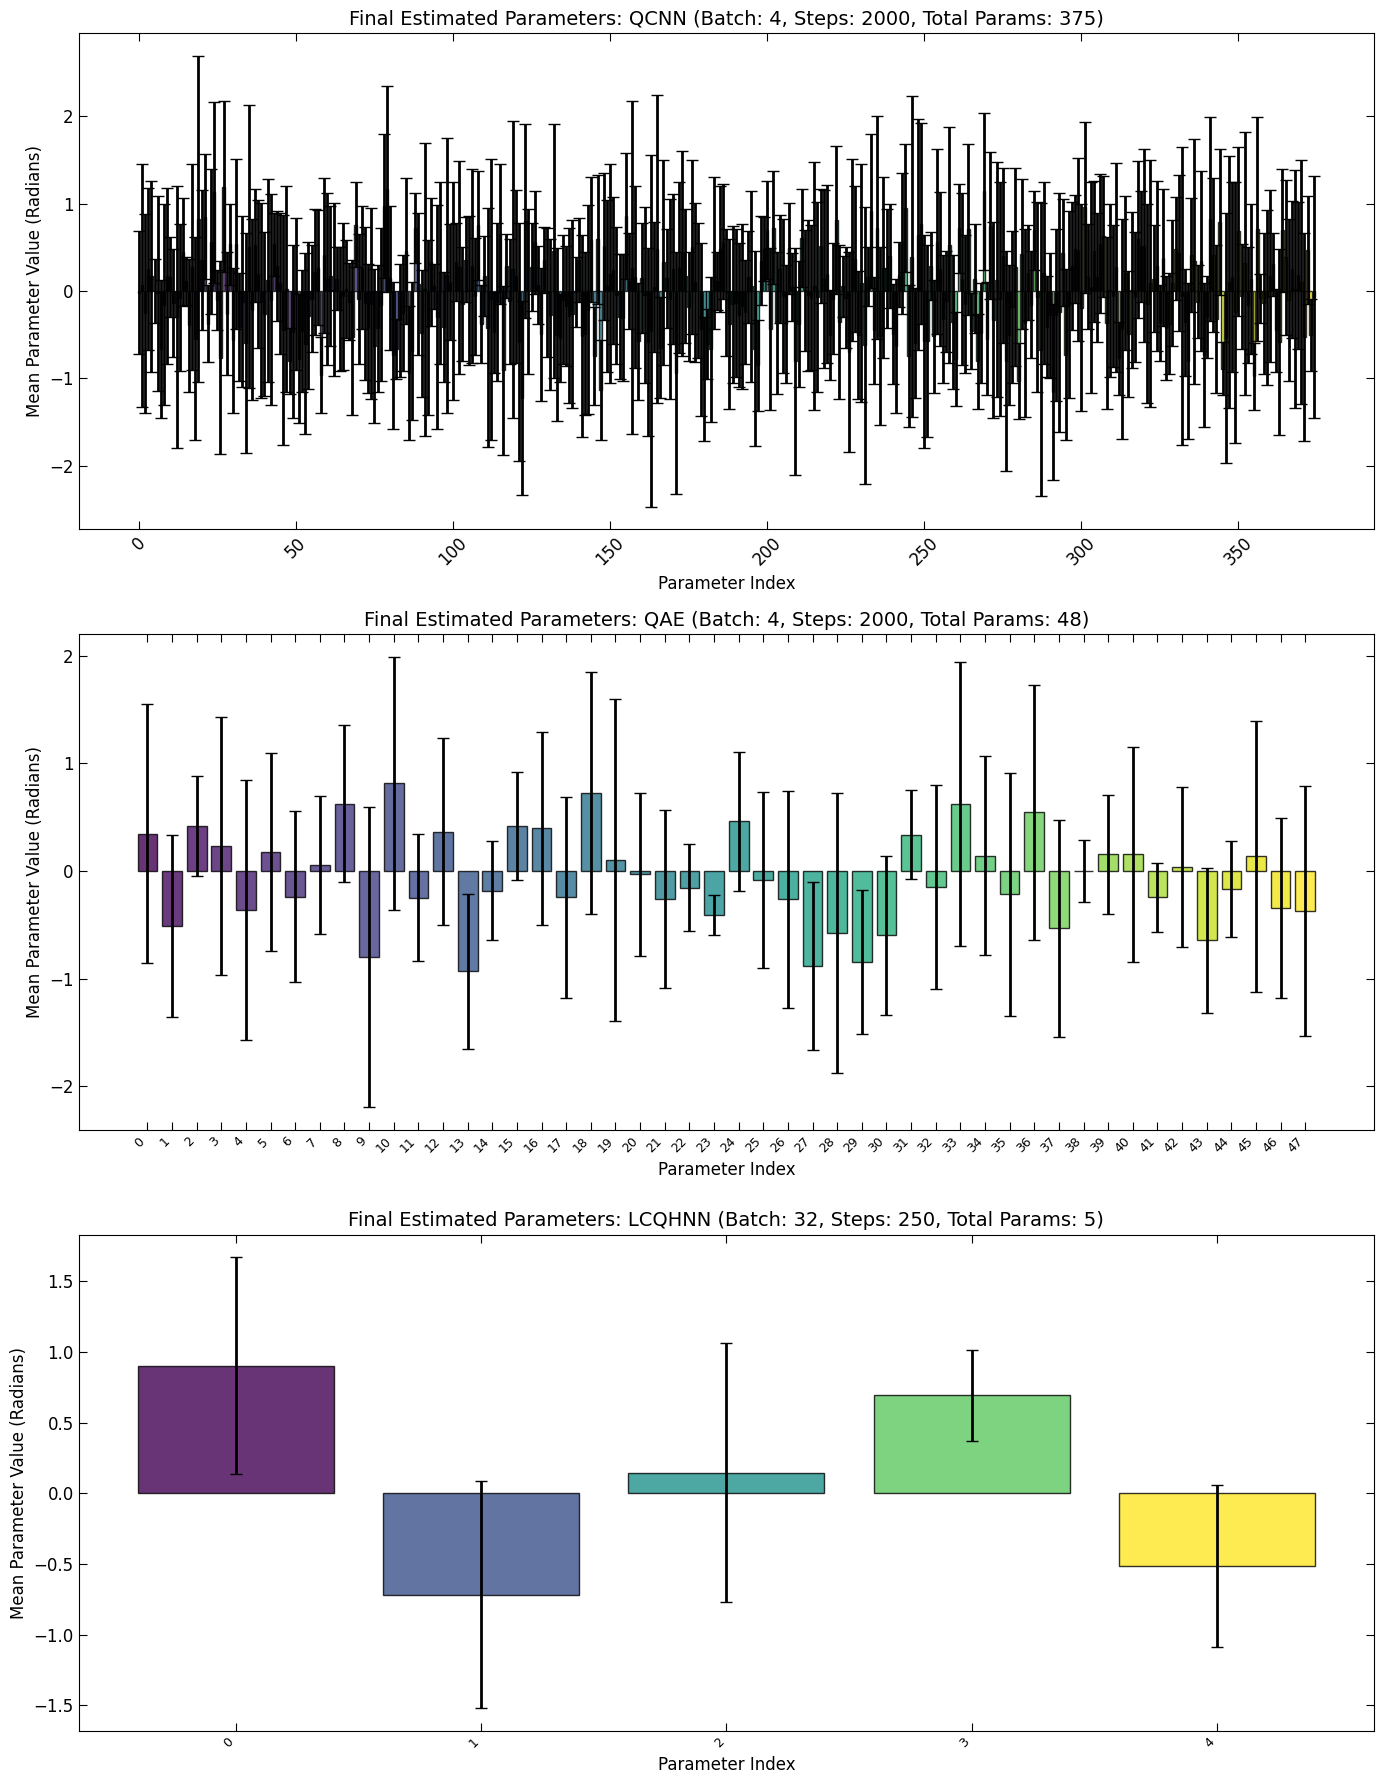

In [21]:
# Define configurations for the best performing models of each ansatz
ansatz_configurations = [
    {'name': 'qcnn', 'batch_size': 4, 'steps': 2000},
    {'name': 'qae', 'batch_size': 4, 'steps': 2000},
    {'name': 'lcqhnn', 'batch_size': 32, 'steps': 250}
]

# Create a figure with 3 vertically stacked subplots
figure, axes = plt.subplots(3, 1, figsize=(14, 18))

for index, config in enumerate(ansatz_configurations):
    ansatz_type = config['name']
    training_batch = config['batch_size']
    training_steps = config['steps']
    current_axis = axes[index]

    # Use the generalized load_data function to fetch EST PARAMS MEAN
    estimated_parameters = load_data("EST PARAMS MEAN", ansatz_type, training_batch, training_steps)

    if estimated_parameters is not None:
        # Check if the data is a 2D array (multiple runs) or 1D array (single run)
        if estimated_parameters.ndim > 1:
            mean_parameters = np.mean(estimated_parameters, axis=0)
            std_parameters = np.std(estimated_parameters, axis=0)
        else:
            mean_parameters = estimated_parameters
            std_parameters = np.zeros_like(mean_parameters) # No variation if only one run

        total_parameters = len(mean_parameters)
        parameter_indices = np.arange(total_parameters)

        # Generate a distinct color for each parameter bar to match our previous plots
        bar_colors = cm.viridis(np.linspace(0, 1, total_parameters))

        # Create a bar chart with error bars to show variance across the 5 runs
        current_axis.bar(
            parameter_indices,
            mean_parameters,
            yerr=std_parameters,
            color=bar_colors,
            alpha=0.8,
            capsize=4,       # Adds the little horizontal caps to the error bars
            edgecolor='black'
        )

        current_axis.set_title(f'Final Estimated Parameters: {ansatz_type.upper()} (Batch: {training_batch}, Steps: {training_steps}, Total Params: {total_parameters})')
        current_axis.set_xlabel('Parameter Index')
        current_axis.set_ylabel('Mean Parameter Value (Radians)')

        # Clean up the x-axis ticks to show integer indices clearly
        # Only label every tick if there are 50 or fewer parameters to prevent text overlap
        if total_parameters <= 50:
            current_axis.set_xticks(parameter_indices)
            current_axis.set_xticklabels(parameter_indices, rotation=45, ha='right', fontsize=9)
        else:
            # If there are many parameters, let matplotlib handle the tick spacing automatically
            current_axis.tick_params(axis='x', rotation=45)

    else:
        current_axis.set_title(f'{ansatz_type.upper()} Estimated Parameters Data Not Found')
        current_axis.axis('off')

# Ensure the subplots do not overlap
plt.tight_layout()
plt.show()